In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
def index_first_high(array_1D):
    """
    Input: 1D np array with just 0s and 1s
    Return: the index of the first occurance of 1 in the array
    """
    starting_index = np.where(array_1D == 1)[0][0] if np.any(array_1D == 1) else None
    return starting_index


def print_min_max(array):
    """
    reutrns the maximum and minimum absulute value in the array
    """
    print(f"{np.min(np.abs(array))} <-> {np.max(np.abs(array))}")


def db(value):
    """ Convert linear value to dB value """
    return 20. * np.log10(np.abs(value) + 1e-12)


def db_relative(value):
    """ Convert linear value to dB value, normalize max to 0dB """
    magnitude = np.abs(value)
    return 20. * np.log10(magnitude / np.max(magnitude) + 1e-12)


def wrap_angle(angle):
    # Convert an angle in rad to the range [-pi,pi]
    return np.arctan2(np.sin(angle), np.cos(angle))


def compute_crest_factor(signal):
    peak_value = np.max(np.abs(signal))
    rms_value = np.sqrt(np.mean(np.abs(signal) ** 2))
    crest_factor = 20 * np.log10(peak_value / rms_value)
    return crest_factor

test signal range: 
0.8598589997989329 <-> 86.306914368799
crest factor:  8.617912234795156


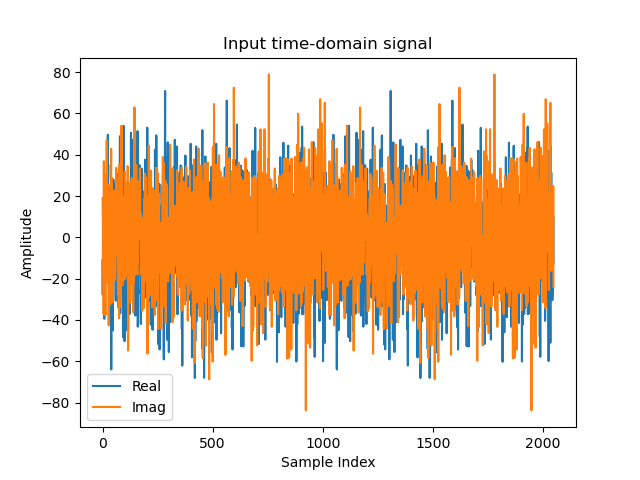

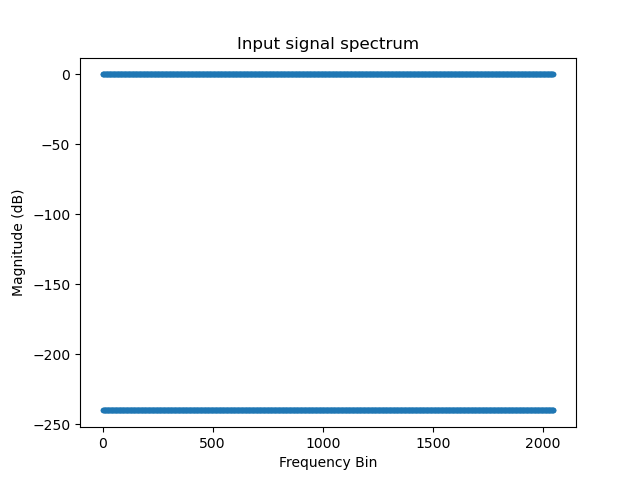

In [3]:
# Ideal test signal
np.random.seed(2061518388)

X = np.zeros(2048, dtype='complex')
rand_phase = np.random.uniform(-np.pi, np.pi, size=2048)
X[::2] = 1.0 * np.exp(1j * rand_phase[::2])  # even bins set to 1.0, odd bins set to 0.0
x = np.fft.ifft(X) * 2048  # time-domain signal
print("test signal range: ")
print_min_max(x)
print("crest factor: ", compute_crest_factor(x))

plt.figure()
plt.plot(np.real(x), label='Real')
plt.plot(np.imag(x), label='Imag')
plt.title('Input time-domain signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

plt.figure()
plt.plot(db(np.fft.fft(x, 2048) / 2048), '.')
plt.title('Input signal spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude (dB)')

np.savetxt('input_files/in_re.csv', np.real(x).reshape(-1, 4), delimiter=',')
np.savetxt('input_files/in_im.csv', np.imag(x).reshape(-1, 4), delimiter=',')

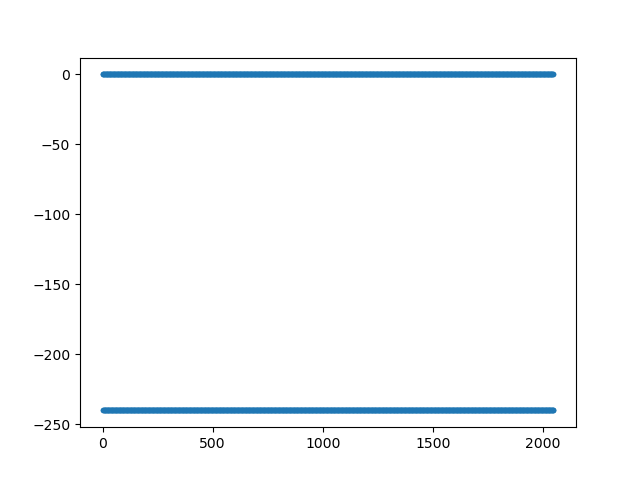

In [7]:
def quantize_complex_to_int16(x, headroom_db=0.0, dither=False, seed=None):
    """
    Quantize complex float array x to signed 16-bit I/Q.
    Returns:
      xi_int16, xq_int16, scale
    where reconstructed float is:
      xq = (xi_int16 + 1j*xq_int16) / scale
    """
    rng = np.random.default_rng(seed)

    # Peak across I and Q components (since each is quantized separately)
    peak = max(np.max(np.abs(x.real)), np.max(np.abs(x.imag)))
    if peak == 0:
        return np.zeros_like(x.real, dtype=np.int16), np.zeros_like(x.real, dtype=np.int16), 1.0

    fullscale = np.int16(32767).astype(np.float64)

    # Optional headroom (useful if you expect occasional peaks)
    headroom = 10**(-headroom_db/20)
    scale = (fullscale * headroom) / peak

    xr = x.real * scale
    xi = x.imag * scale

    # Optional TPDF dither (~1 LSB p-p) to decorrelate quantization error
    if dither:
        # TPDF in [-1,1] LSB units (approximately)
        d = (rng.random(x.shape) - rng.random(x.shape))
        xr = xr + d
        xi = xi + d

    # Round-to-nearest quantization + clipping
    xr_q = np.clip(np.round(xr), -32768, 32767).astype(np.int16)
    xi_q = np.clip(np.round(xi), -32768, 32767).astype(np.int16)

    return xr_q, xi_q, scale

# Example usage:
xr16, xi16, scale = quantize_complex_to_int16(x, headroom_db=0.0, seed=0)
x16 = (xr16.astype(np.float64) + 1j*xi16.astype(np.float64)) / scale
X16 = np.fft.fft(x16)
spec_db = 20*np.log10(np.abs(X16) + 1e-300)
plt.figure()
plt.plot(db_relative(np.fft.fft(x16)), '.')
plt.show()

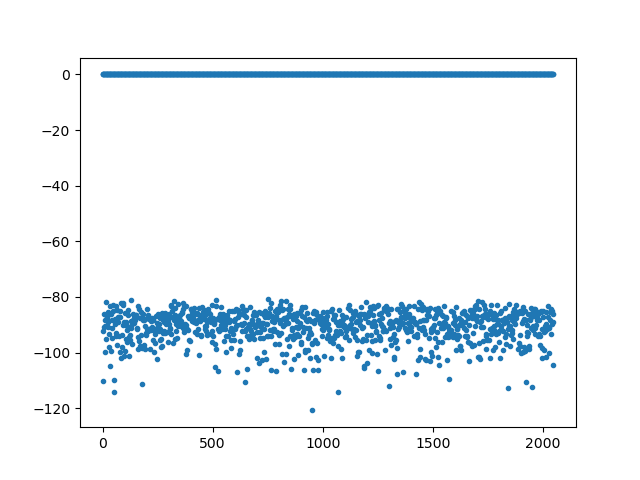

In [12]:
def quantize_complex(
    x,
    n_bits=16,
    headroom_db=0.0,
    dither=False,
    seed=None,
    rounding="trunc",   # "nearest" or "trunc"
    saturate=True,
    return_dtype=np.int16
):
    """
    Quantize complex float array x to signed n_bits I/Q (I and Q quantized separately).

    Returns:
      xr_q, xi_q, scale, overflow

    Reconstruct:
      x_rec = (xr_q + 1j*xi_q) / scale
    """
    if n_bits < 2:
        raise ValueError("n_bits must be >= 2 for a signed quantizer.")

    rng = np.random.default_rng(seed)

    # Signed n-bit range
    qmin = -(1 << (n_bits - 1))
    qmax =  (1 << (n_bits - 1)) - 1
    fullscale = float(qmax)

    # Peak across I/Q
    peak = max(np.max(np.abs(x.real)), np.max(np.abs(x.imag)))
    if peak == 0:
        z = np.zeros_like(x.real, dtype=return_dtype)
        return z, z, 1.0, False

    # Scaling with optional headroom
    headroom = 10 ** (-headroom_db / 20)
    scale = (fullscale * headroom) / peak

    xr = x.real * scale
    xi = x.imag * scale

    # Optional TPDF dither (~1 LSB p-p)
    if dither:
        d = (rng.random(x.shape) - rng.random(x.shape))
        xr += d
        xi += d

    # Quantization (float domain)
    if rounding == "nearest":
        xr_qf = np.round(xr)
        xi_qf = np.round(xi)
    elif rounding == "trunc":
        xr_qf = np.trunc(xr)
        xi_qf = np.trunc(xi)
    else:
        raise ValueError("rounding must be 'nearest' or 'trunc'.")

    # ---- Overflow detection (pre-saturation) ----
    overflow = (
        np.any(xr_qf < qmin) or np.any(xr_qf > qmax) or
        np.any(xi_qf < qmin) or np.any(xi_qf > qmax)
    )

    # Saturation
    if saturate:
        xr_qf = np.clip(xr_qf, qmin, qmax)
        xi_qf = np.clip(xi_qf, qmin, qmax)

    xr_q = xr_qf.astype(return_dtype)
    xi_q = xi_qf.astype(return_dtype)

    return xr_q, xi_q, scale, overflow

# Example usage:
xr12, xi12, scale, overflow = quantize_complex(x, n_bits=16, dither=True)
x12 = (xr12.astype(np.float64) + 1j*xi12.astype(np.float64)) / scale
X12 = np.fft.fft(x12)
spec_db = 20*np.log10(np.abs(X12) + 1e-300)
plt.figure()
plt.plot(db_relative(np.fft.fft(x12)), '.')
plt.show()